In [2]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index (1).csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [22]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [28]:
print("Missing values in trades:")
print(trades.isnull().sum())

print("\nMissing values in sentiment:")
print(sentiment.isnull().sum())

Missing values in trades:
Account                  0
Coin                     0
Execution Price          0
Size Tokens              0
Size USD                 0
Side                     0
Timestamp IST            0
Start Position           0
Direction                0
Closed PnL               0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp                0
date                131999
dtype: int64

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [29]:
trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

print("Trades after removing duplicates:", trades.shape)
print("Sentiment after removing duplicates:", sentiment.shape)

Trades after removing duplicates: (211224, 17)
Sentiment after removing duplicates: (2644, 4)


In [31]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [32]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce').dt.date

In [33]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,02-12-2024 22:50,2024-02-12
1,02-12-2024 22:50,2024-02-12
2,02-12-2024 22:50,2024-02-12
3,02-12-2024 22:50,2024-02-12
4,02-12-2024 22:50,2024-02-12


In [34]:
data = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [35]:
data['win'] = data['Closed PnL'] > 0

In [36]:
data['trade_size'] = data['Size USD']

In [37]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


In [38]:
win_rate = data.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [39]:
avg_trade_size = data.groupby('Account')['trade_size'].mean().reset_index()

avg_trade_size.head()

,Account,trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [40]:
long_short_ratio = data['Side'].value_counts(normalize=True)

print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


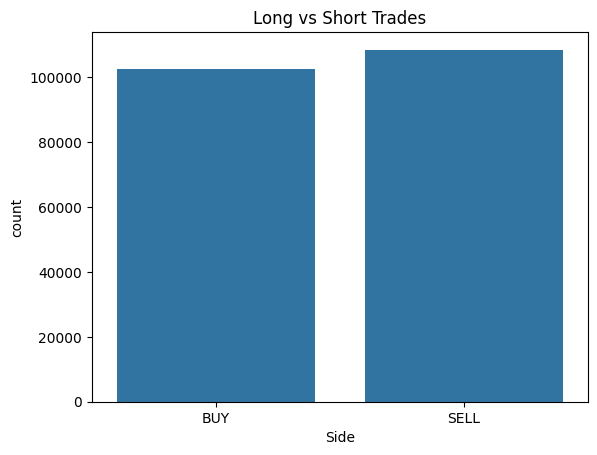

In [41]:
sns.countplot(x='Side', data=data)
plt.title("Long vs Short Trades")
plt.show()

In [42]:
pnl_sentiment = data.groupby('classification')['Closed PnL'].mean()

print(pnl_sentiment)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


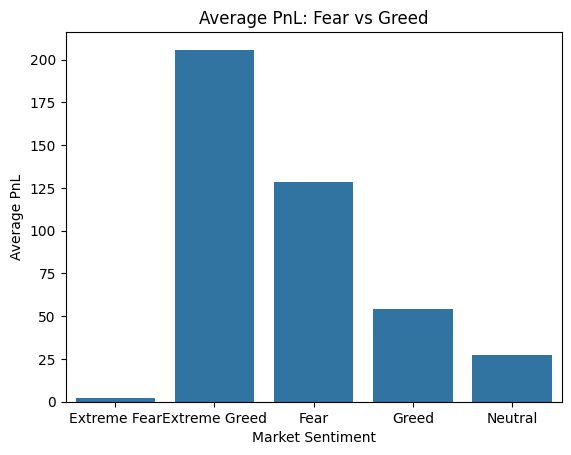

In [43]:
sns.barplot(x=pnl_sentiment.index, y=pnl_sentiment.values)

plt.title("Average PnL: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

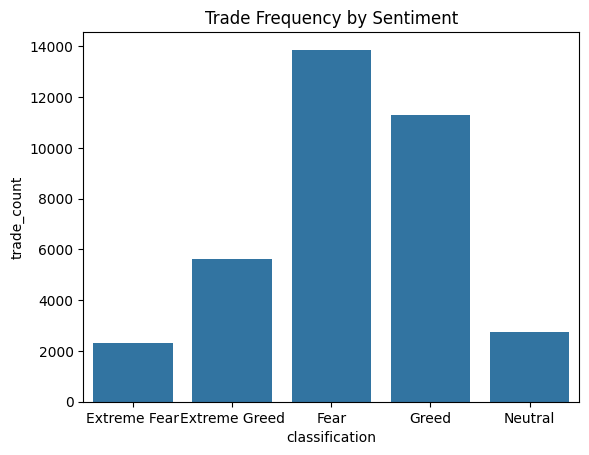

In [44]:
trade_freq = data.groupby(['classification']).size().reset_index(name='trade_count')

sns.barplot(x='classification', y='trade_count', data=trade_freq)

plt.title("Trade Frequency by Sentiment")
plt.show()

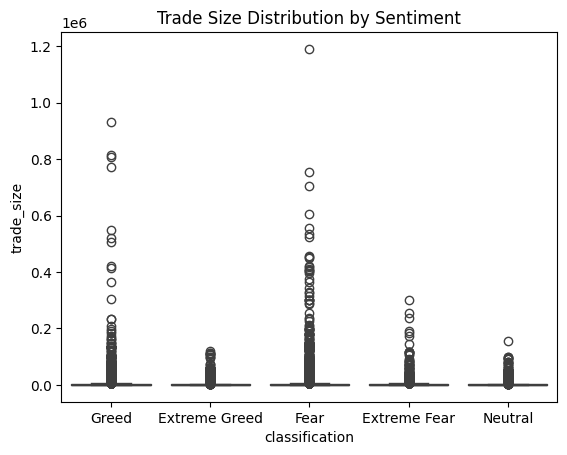

In [45]:
sns.boxplot(x='classification', y='trade_size', data=data)

plt.title("Trade Size Distribution by Sentiment")
plt.show()

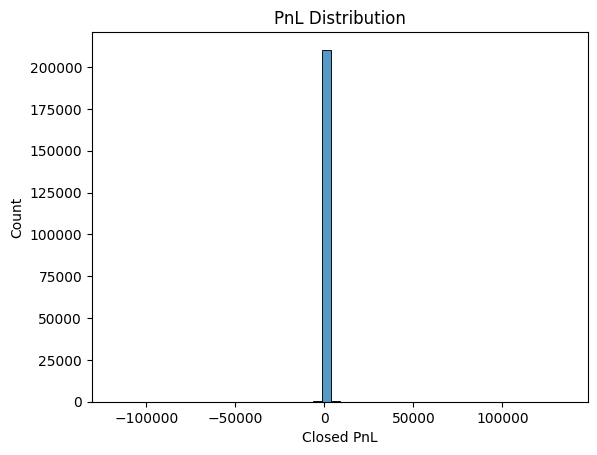

In [46]:
sns.histplot(data['Closed PnL'], bins=50)

plt.title("PnL Distribution")
plt.show()

In [47]:
median_size = data['trade_size'].median()

data['trader_segment'] = np.where(
    data['trade_size'] > median_size,
    'High Size Trader',
    'Low Size Trader'
)

In [48]:
segment_perf = data.groupby('trader_segment')['Closed PnL'].mean()

print(segment_perf)

trader_segment
High Size Trader    93.116556
Low Size Trader      4.381445
Name: Closed PnL, dtype: float64


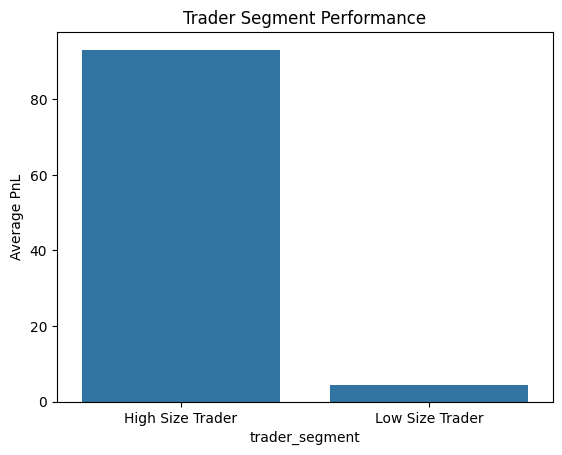

In [49]:
sns.barplot(x=segment_perf.index, y=segment_perf.values)

plt.title("Trader Segment Performance")
plt.ylabel("Average PnL")

plt.show()